In [2]:
!python -m pip install lightning
!pip install thop


In [3]:
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F        # ← F должен быть ТОЛЬКО этот
import torchaudio
import torchaudio.functional as TAF    # ← torchaudio через отдельный алиас
import pytorch_lightning as pl


class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super().__init__()
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        self.window = torch.hann_window(self.window_length)
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power


        self.f_min_hz = f_min_hz
        self.f_max_hz = f_max_hz if f_max_hz is not None else float(self.samplerate // 2)
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale


        self.mel_fbanks = self._init_melscale_fbanks()

    def _init_melscale_fbanks(self):
        return TAF.melscale_fbanks(
             self.n_fft // 2 + 1,
            f_min=self.f_min_hz,
            f_max=self.f_max_hz,
            n_mels=self.n_mels,
            sample_rate=self.samplerate,
            norm=self.norm_mel,
            mel_scale=self.mel_scale        )

    def spectrogram(self, x):
        return torch.stft(
            input=x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            window=self.window,
            center=self.center,
            pad_mode=self.pad_mode,
            return_complex=self.return_complex,
            onesided=self.onesided
        )

    def forward(self, x):
        """
        Args:
            x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
        Returns:
            Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
                where n_frames is a function of the window_length, hop_length and length of audio
        """
        stft_output = self.spectrogram(x)

        # Calculate power spectrum
        # For complex STFT output (which is default for return_complex=True),
        # power spectrum is magnitude squared
        power_spectrum = torch.abs(stft_output).pow(self.power)

        # Apply mel filter banks
        # The output of stft is (batch, freq_bins, frames).
        # For matmul with mel_fbanks (freq_bins, n_mels), we need (batch, frames, freq_bins) @ (freq_bins, n_mels)
        # Then transpose back to (batch, n_mels, frames)
        mel_spectrogram = torch.matmul(power_spectrum.transpose(-1, -2), self.mel_fbanks).transpose(-1, -2)

        # Apply logarithm, adding a small epsilon for numerical stability
        log_mel_spectrogram = torch.log(mel_spectrogram + 1e-6)

        return log_mel_spectrogram

In [4]:
root="./"

In [5]:
from torch.utils.data import Subset, DataLoader
from torchaudio.datasets import SPEECHCOMMANDS

import os

def filter_yes_no(dataset):
    indices = []
    for i, path in enumerate(dataset._walker):
        label = os.path.basename(os.path.dirname(path))
        if label in ("yes", "no"):
            indices.append(i)
    return indices

train_set = SPEECHCOMMANDS(root, subset="training", download=True)
val_set   = SPEECHCOMMANDS(root, subset="validation", download=True)
test_set  = SPEECHCOMMANDS(root, subset="testing", download=True)

train_yesno = Subset(train_set, filter_yes_no(train_set))
val_yesno   = Subset(val_set, filter_yes_no(val_set))
test_yesno  = Subset(test_set, filter_yes_no(test_set))

100%|██████████| 2.26G/2.26G [00:17<00:00, 140MB/s]


In [6]:
signal = train_yesno.__getitem__(100)[0][0]
signal

tensor([1.2207e-04, 2.7466e-04, 2.7466e-04,  ..., 1.8311e-04, 9.1553e-05,
        1.8311e-04])

In [7]:
from IPython.display import Audio

Audio(signal.numpy(), rate=16000)

In [8]:
import torchaudio
import librosa

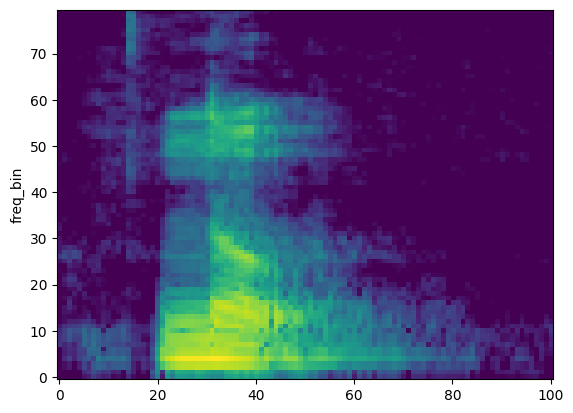

In [9]:
import matplotlib.pyplot as plt
def plot_fbank(fbank, title=None):
    fig, axs = plt.subplots(1, 1)
    axs.set_title(title or "Filter bank")
    axs.imshow(fbank, aspect="auto")
    axs.set_ylabel("frequency bin")
    axs.set_xlabel("mel bin")



def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")

melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)


plot_spectrogram(melspec)

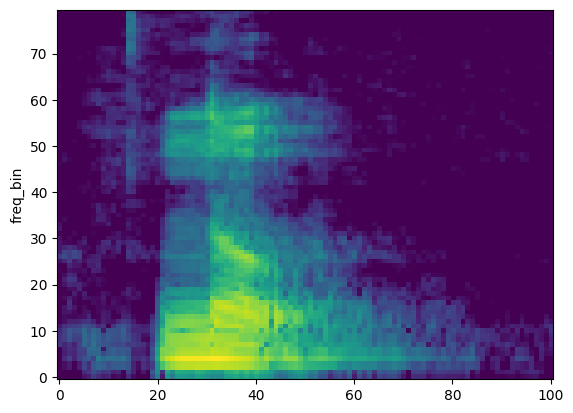

In [10]:
logmelbanks = LogMelFilterBanks(hop_length=160,
    n_mels=80)(signal)

plot_spectrogram(melspec)

In [11]:
melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)
logmelbanks = LogMelFilterBanks()(signal)

torch.log(melspec + 1e-6).shape == logmelbanks.shape, torch.allclose(torch.log(melspec + 1e-6), logmelbanks)

(True, True)

In [12]:
import time
import torch
import pytorch_lightning as pl
import os

TARGET_CLASSES = ["yes", "no"]


def make_collate_fn(transform):
    def collate_fn(batch):
        waveforms, labels = [], []
        for waveform, sample_rate, label, *_ in batch:
            length = waveform.shape[-1]
            if length < 16000:
                waveform = torch.nn.functional.pad(waveform, (0, 16000 - length))
            else:
                waveform = waveform[..., :16000]

            waveform = transform(waveform)   # → (1, n_mels, T)
            waveform = waveform.squeeze(0)   # → (n_mels, T)  ← фикс

            waveforms.append(waveform)
            labels.append(TARGET_CLASSES.index(label))

        return torch.stack(waveforms), torch.tensor(labels)
    return collate_fn

# ─────────────────────────────────────────
# 3. MODEL
# ─────────────────────────────────────────

class AudioCNN(nn.Module):
    def __init__(self, n_mels=40, groups=1):
        super().__init__()
        # groups применяем только там где делится без остатка (блоки 2 и 3)
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(n_mels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 64, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.classifier(self.conv_blocks(x))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def count_flops(self, n_mels):
        from thop import profile
        # ~100 фреймов для 1 сек аудио с hop_length=160
        dummy = torch.zeros(1, n_mels, 100)
        flops, _ = profile(self, inputs=(dummy,), verbose=False)
        return int(flops)


# ─────────────────────────────────────────
# 4. LIGHTNING MODULE
# ─────────────────────────────────────────

class SpeechLitModule(pl.LightningModule):
    def __init__(self, n_mels=40, groups=1, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = AudioCNN(n_mels=n_mels, groups=groups)
        self._epoch_start_time = None

    def on_train_epoch_start(self):
        self._epoch_start_time = time.time()

    def training_step(self, batch, batch_idx):
      x, y = batch
      loss = torch.nn.functional.cross_entropy(self.model(x), y)
      self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
      return loss

    def on_train_epoch_end(self):
        elapsed = time.time() - self._epoch_start_time
        self.log("epoch_time_sec", elapsed)

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self.model(x).argmax(dim=1)
        acc = (preds == y).float().mean()
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        preds = self.model(x).argmax(dim=1)
        acc = (preds == y).float().mean()
        self.log("test_acc", acc, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [13]:
def run_experiment(n_mels=40, groups=1, max_epochs=20, batch_size=64):
    # Создаём transform с нужным n_mels
    transform = LogMelFilterBanks(hop_length=160, n_mels=n_mels)
    collate_fn = make_collate_fn(transform)

    train_loader = DataLoader(train_yesno, batch_size=batch_size,
                              shuffle=True,  collate_fn=collate_fn, num_workers=4)
    val_loader   = DataLoader(val_yesno,   batch_size=batch_size,
                              shuffle=False, collate_fn=collate_fn, num_workers=4)
    test_loader  = DataLoader(test_yesno,  batch_size=batch_size,
                              shuffle=False, collate_fn=collate_fn, num_workers=4)

    module = SpeechLitModule(n_mels=n_mels, groups=groups)

    # Печатаем параметры и FLOPs до обучения
    print(f"Parameters : {module.model.count_parameters():,}")
    print(f"FLOPs      : {module.model.count_flops(n_mels):,}")

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        log_every_n_steps=10,
    )

    trainer.fit(module, train_loader, val_loader)
    test_results = trainer.test(module, test_loader)

    # Достаём залогированные метрики по всем эпохам
    metrics = trainer.logged_metrics
    return test_results[0]["test_acc"], metrics, trainer

In [14]:
results_mels = {}   # n_mels → test_acc

for n_mels in [20, 40, 80]:
    print(f"\n{'='*45}\nn_mels = {n_mels}\n{'='*45}")
    test_acc, metrics, trainer = run_experiment(n_mels=n_mels, groups=1, max_epochs=20)
    results_mels[n_mels] = {
        "test_acc": test_acc,
        "trainer":  trainer,   # хранит историю для графиков
    }

print("\n=== n_mels sweep ===")
for k, v in results_mels.items():
    print(f"  n_mels={k:2d}  →  test_acc={v['test_acc']:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and v


n_mels = 20
Parameters : 22,978
FLOPs      : 842,176


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ AudioCNN │ 23.0 K │ train │     0 │
└───┴───────┴──────────┴────────┴───────┴───────┘

Trainable params: 23.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9915048480033875     │
└───────────────────────────┴───────────────────────────┘


=== n_mels sweep ===
  n_mels=20  →  test_acc=0.9806
  n_mels=40  →  test_acc=0.9951
  n_mels=80  →  test_acc=0.9915


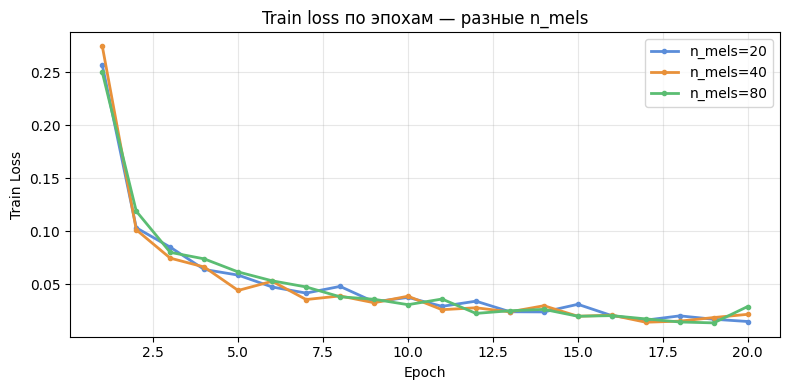

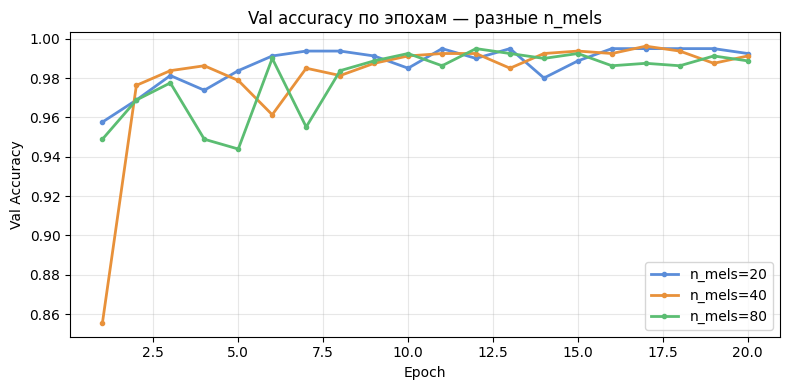

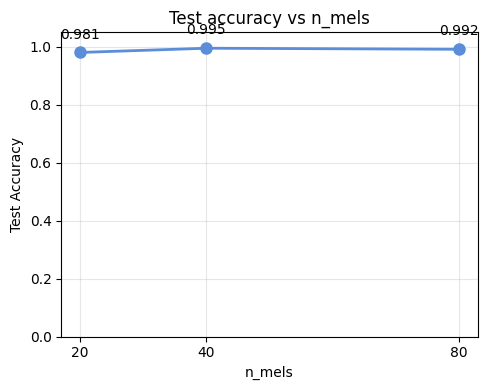

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


# ─────────────────────────────────────────
# ХЕЛПЕР: достать историю метрики из trainer
# ─────────────────────────────────────────

def get_metric_history(trainer, metric_name):
    """Возвращает список значений метрики по эпохам из callback_metrics."""
    history = []
    for logged in trainer.logger.experiment.metrics:  # TensorBoard / CSV logger
        if metric_name in logged:
            history.append(logged[metric_name])
    return history

# Если используешь дефолтный CSVLogger — удобнее читать напрямую:
import pandas as pd

def read_tb_metrics(trainer):
    """Читает метрики из TensorBoard event файла."""
    log_dir = trainer.logger.log_dir
    ea = EventAccumulator(log_dir)
    ea.Reload()

    result = {}
    for tag in ea.Tags()["scalars"]:
        events = ea.Scalars(tag)
        result[tag] = [e.value for e in events]

    return result

# ─────────────────────────────────────────
# П.2  ГРАФИК 1: Train Loss по эпохам
#               для каждого n_mels
# ─────────────────────────────────────────

# Использование в графиках:
def plot_train_loss_by_mels(results_mels):
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = {20: "#5B8DD9", 40: "#E8913A", 80: "#5BBD72"}

    for n_mels, res in results_mels.items():
        metrics = read_tb_metrics(res["trainer"])
        loss = metrics["train_loss"]
        epochs = range(1, len(loss) + 1)
        ax.plot(epochs, loss, label=f"n_mels={n_mels}",
                color=colors[n_mels], linewidth=2, marker="o", markersize=3)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train Loss")
    ax.set_title("Train loss по эпохам — разные n_mels")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("plot_loss_by_mels.png", dpi=150)
    plt.show()


def plot_val_acc_by_mels(results_mels):
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = {20: "#5B8DD9", 40: "#E8913A", 80: "#5BBD72"}

    for n_mels, res in results_mels.items():
        metrics = read_tb_metrics(res["trainer"])
        acc = metrics["val_acc"]
        epochs = range(1, len(acc) + 1)
        ax.plot(epochs, acc, label=f"n_mels={n_mels}",
                color=colors[n_mels], linewidth=2, marker="o", markersize=3)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Accuracy")
    ax.set_title("Val accuracy по эпохам — разные n_mels")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("plot_val_acc_by_mels.png", dpi=150)
    plt.show()


def plot_accuracy_vs_mels(results_mels):
    fig, ax = plt.subplots(figsize=(5, 4))

    mels_vals = sorted(results_mels.keys())
    acc_vals  = [results_mels[m]["test_acc"] for m in mels_vals]

    ax.plot(mels_vals, acc_vals, color="#5B8DD9", linewidth=2,
            marker="o", markersize=8, zorder=3)

    # Подписи значений над точками
    for x, y in zip(mels_vals, acc_vals):
        ax.annotate(f"{y:.3f}", (x, y),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=10)

    ax.set_xticks(mels_vals)
    ax.set_xlabel("n_mels")
    ax.set_ylabel("Test Accuracy")
    ax.set_title("Test accuracy vs n_mels")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("plot_acc_vs_mels.png", dpi=150)
    plt.show()


# ─────────────────────────────────────────
# П.3  ГРАФИК 4: Epoch Time vs Groups
# ─────────────────────────────────────────

def plot_epoch_time_vs_groups(results_groups):
    fig, ax = plt.subplots(figsize=(6, 4))

    g_vals = sorted(results_groups.keys())
    t_vals = [results_groups[g]["mean_epoch_time"] for g in g_vals]

    ax.bar([str(g) for g in g_vals], t_vals, color="#5B8DD9", width=0.5)
    for i, (g, t) in enumerate(zip(g_vals, t_vals)):
        ax.text(i, t + 0.01, f"{t:.2f}s", ha="center", fontsize=9)

    ax.set_xlabel("groups")
    ax.set_ylabel("Среднее время эпохи (сек)")
    ax.set_title("Epoch training time vs groups")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("plot_time_vs_groups.png", dpi=150)
    plt.show()


# ─────────────────────────────────────────
# П.3  ГРАФИК 5: Params & FLOPs vs Groups
# ─────────────────────────────────────────

def plot_params_flops_vs_groups(results_groups):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    g_vals  = sorted(results_groups.keys())
    p_vals  = [results_groups[g]["params"] / 1e3 for g in g_vals]   # в тысячах
    fl_vals = [results_groups[g]["flops"]  / 1e6 for g in g_vals]   # в миллионах

    # Параметры
    ax1.plot([str(g) for g in g_vals], p_vals, color="#E8913A",
             linewidth=2, marker="o", markersize=8)
    for i, (g, p) in enumerate(zip(g_vals, p_vals)):
        ax1.annotate(f"{p:.1f}K", (i, p),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax1.set_xlabel("groups")
    ax1.set_ylabel("Параметры (K)")
    ax1.set_title("Число параметров vs groups")
    ax1.grid(True, alpha=0.3)

    # FLOPs
    ax2.plot([str(g) for g in g_vals], fl_vals, color="#5BBD72",
             linewidth=2, marker="o", markersize=8)
    for i, (g, fl) in enumerate(zip(g_vals, fl_vals)):
        ax2.annotate(f"{fl:.1f}M", (i, fl),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax2.set_xlabel("groups")
    ax2.set_ylabel("FLOPs (M)")
    ax2.set_title("FLOPs vs groups")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("plot_params_flops_vs_groups.png", dpi=150)
    plt.show()


# ─────────────────────────────────────────
# П.3  ГРАФИК 6: Test Accuracy vs Groups
# ─────────────────────────────────────────

def plot_accuracy_vs_groups(results_groups):
    fig, ax = plt.subplots(figsize=(6, 4))

    g_vals   = sorted(results_groups.keys())
    acc_vals = [results_groups[g]["test_acc"] for g in g_vals]

    ax.plot([str(g) for g in g_vals], acc_vals, color="#9B72CF",
            linewidth=2, marker="o", markersize=8, zorder=3)
    for i, (g, a) in enumerate(zip(g_vals, acc_vals)):
        ax.annotate(f"{a:.3f}", (i, a),
                    textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

    ax.set_xlabel("groups")
    ax.set_ylabel("Test Accuracy")
    ax.set_title("Test accuracy vs groups")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("plot_acc_vs_groups.png", dpi=150)
    plt.show()


# ─────────────────────────────────────────
# ВЫЗОВ ВСЕХ ГРАФИКОВ
# ─────────────────────────────────────────

# После завершения sweep по n_mels:
plot_train_loss_by_mels(results_mels)
plot_val_acc_by_mels(results_mels)
plot_accuracy_vs_mels(results_mels)

In [42]:
BEST_N_MELS = 40

In [47]:
# ─────────────────────────────────────────
# П.3  SWEEP по groups (запускать после п.2)
# ─────────────────────────────────────────

GROUPS_LIST = [2, 4, 8, 16]

results_groups = {}  # groups → {test_acc, params, flops, epoch_time}

for groups in GROUPS_LIST:
    print(f"\n{'='*45}\ngroups = {groups}\n{'='*45}")
    test_acc, metrics, trainer = run_experiment(
        n_mels=BEST_N_MELS, groups=groups, max_epochs=20
    )

    # Параметры и FLOPs
    tmp_model = AudioCNN(n_mels=BEST_N_MELS, groups=groups)
    params = tmp_model.count_parameters()
    flops  = tmp_model.count_flops(BEST_N_MELS)

    # Среднее время эпохи из TensorBoard
    metrics = read_tb_metrics(trainer)
    mean_epoch_time = sum(metrics["epoch_time_sec"]) / len(metrics["epoch_time_sec"])

    results_groups[groups] = {
        "test_acc":        test_acc,
        "params":          params,
        "flops":           flops,
        "mean_epoch_time": mean_epoch_time,
        "trainer":         trainer,
    }


groups = 2
Parameters : 13,762
FLOPs      : 534,976


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ AudioCNN │ 13.8 K │ train │     0 │
└───┴───────┴──────────┴────────┴───────┴───────┘

Trainable params: 13.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9939320683479309     │
└───────────────────────────┴───────────────────────────┘

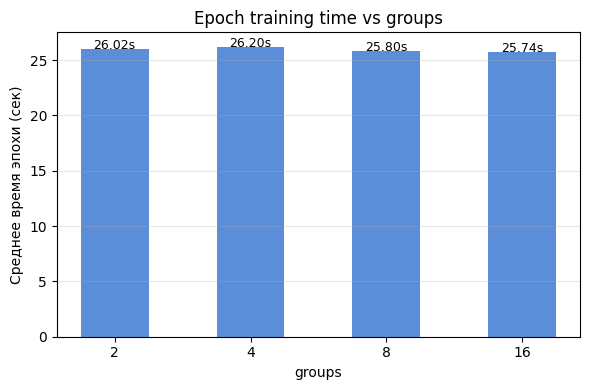

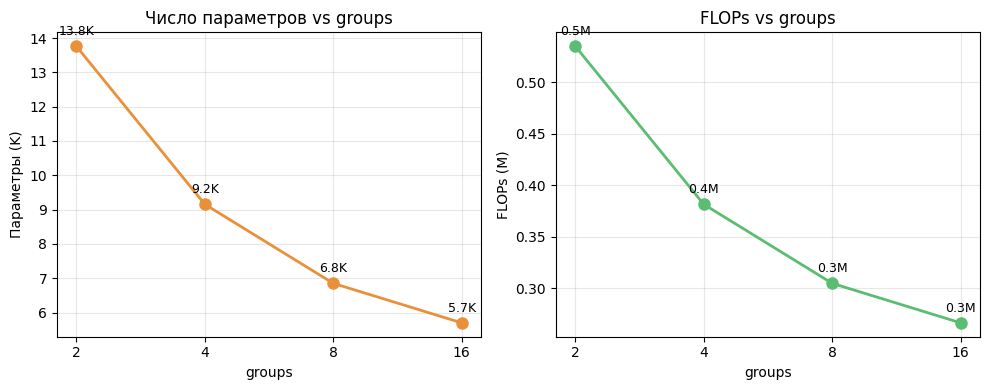

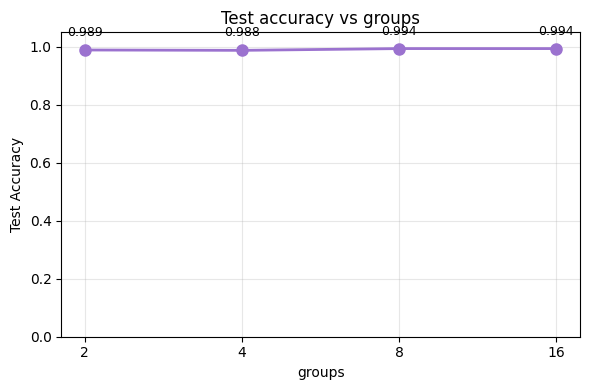

In [48]:
# После завершения sweep по groups:
plot_epoch_time_vs_groups(results_groups)
plot_params_flops_vs_groups(results_groups)
plot_accuracy_vs_groups(results_groups)